<a href="https://colab.research.google.com/github/Cado87/Monai_projects/blob/main/Visualizer_nifti_dicom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup
First, we need to install the required libraries: MONAI (with all its dependencies like `pydicom` and `nibabel`), `tqdm` for progress bars, and `matplotlib` for plotting.

In [1]:
!pip install -q "monai[all]" "tqdm" "matplotlib"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.4/81.4 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28

Next, we'll import the necessary modules from `monai`, `pydicom`, `nibabel`, `matplotlib`, and `numpy`.

In [2]:
import os
import tempfile
import matplotlib.pyplot as plt
import numpy as np

import pydicom
import nibabel as nib

from monai.transforms import LoadImage, Orientation, ScaleIntensityRange, Resize, Compose
from monai.data import decollate_batch
from monai.visualize import plot_2d_or_3d_image
from monai.utils import first

## Download Sample NIfTI Dataset
We'll download a small brain MRI dataset (BraTS 2018) from MONAI's public resources to use as real NIfTI data. This involves using `gdown` to download a zipped file and then extracting its contents.

In [19]:
from monai.apps import download_and_extract
import os
import shutil # Added for rmtree

# (Assuming data_dir is already defined from cell 74da3722 execution)

# Define the resource URL for Task09_Spleen.tar
resource = "https://msd-for-monai.s3-us-west-2.amazonaws.com/Task09_Spleen.tar"

# Ensure clean extraction by removing existing directory if it exists
extracted_target_dir = os.path.join(data_dir, "Task09_Spleen")
if os.path.exists(extracted_target_dir):
    print(f"Removing existing directory: {extracted_target_dir}")
    shutil.rmtree(extracted_target_dir)

print(f"Downloading and extracting Task09_Spleen dataset to: {data_dir}")
# download_and_extract handles creation of subdirectories
# It will extract to data_dir/Task09_Spleen/
download_and_extract(resource, output_dir=data_dir, file_type="tar")
print("Dataset downloaded and extracted.")

# --- Debugging: Inspect extracted contents ---
print(f"Contents of {data_dir}: {os.listdir(data_dir)}")

# After extraction, Task09_Spleen should exist
if os.path.exists(extracted_target_dir):
    print(f"Contents of {extracted_target_dir}: {os.listdir(extracted_target_dir)}")
    images_tr_dir = os.path.join(extracted_target_dir, "imagesTr")
    if os.path.exists(images_tr_dir):
        # Filter out AppleDouble files (starting with '._')
        actual_nifti_files = [f for f in os.listdir(images_tr_dir) if f.endswith('.nii.gz') and not f.startswith('._')]
        if actual_nifti_files:
            print(f"Actual NIfTI files found in {images_tr_dir}: {actual_nifti_files[:5]}...")
            # Pick the first actual NIfTI file found
            real_nifti_filepath = os.path.join(images_tr_dir, actual_nifti_files[0])

            # Update nifti_filepath to point to a real image from the downloaded dataset
            global nifti_filepath
            nifti_filepath = real_nifti_filepath
            print(f"Updated NIfTI filepath to real data: {nifti_filepath}")
        else:
            print(f"No .nii.gz files found in {images_tr_dir} after filtering. Keeping dummy NIfTI filepath.")
            real_nifti_filepath = None # Indicate it wasn't found
    else:
        print(f"Directory {images_tr_dir} does not exist. Keeping dummy NIfTI filepath.")
        real_nifti_filepath = None
else:
    print(f"Directory {extracted_target_dir} does not exist after download. Keeping dummy NIfTI filepath.")
    real_nifti_filepath = None

# If real_nifti_filepath was not updated, keep the dummy one
if real_nifti_filepath is None:
    print("Keeping the dummy NIfTI filepath for now.")


Removing existing directory: /tmp/tmp1l7mkdic/Task09_Spleen


Task09_Spleen.tar: 1.50GB [01:08, 23.6MB/s]                            

2026-05-26 16:49:21,529 - INFO - Downloaded: /tmp/tmp3orpinct/Task09_Spleen.tar
2026-05-26 16:49:21,531 - INFO - Expected md5 is None, skip md5 check for file /tmp/tmp3orpinct/Task09_Spleen.tar.
2026-05-26 16:49:21,533 - INFO - Writing into directory: /tmp/tmp1l7mkdic.


Dataset downloaded and extracted.
Contents of /tmp/tmp1l7mkdic: ['dummy_dicom_series', 'Task09_Spleen', 'brats_sample.zip', 'dummy_image.nii.gz', '._Task09_Spleen']
Contents of /tmp/tmp1l7mkdic/Task09_Spleen: ['._imagesTs', 'imagesTs', '._imagesTr', 'imagesTr', 'dataset.json', '._dataset.json', '._labelsTr', 'labelsTr']
Actual NIfTI files found in /tmp/tmp1l7mkdic/Task09_Spleen/imagesTr: ['spleen_60.nii.gz', 'spleen_56.nii.gz', 'spleen_32.nii.gz', 'spleen_45.nii.gz', 'spleen_8.nii.gz']...
Updated NIfTI filepath to real data: /tmp/tmp1l7mkdic/Task09_Spleen/imagesTr/spleen_60.nii.gz


Now that we have downloaded the real NIfTI data, the NIfTI visualization section will use this data. We will also adjust the NIfTI visualization code slightly to explicitly load the new `nifti_filepath` after its update.

In [24]:
# Explicitly update nifti_filepath to use the real downloaded data
# This assumes real_nifti_filepath was successfully set in the previous download cell
if 'real_nifti_filepath' in globals() and real_nifti_filepath is not None:
    global nifti_filepath
    nifti_filepath = real_nifti_filepath
    print(f"NIfTI filepath updated to real data: {nifti_filepath}")
else:
    print("real_nifti_filepath not found or is None. NIfTI visualization might still use dummy data.")


NIfTI filepath updated to real data: /tmp/tmp1l7mkdic/Task09_Spleen/imagesTr/spleen_60.nii.gz


To demonstrate the visualizer, we'll create dummy NIfTI and DICOM files in a temporary directory.

In [20]:
# Create a temporary directory for data
data_dir = tempfile.mkdtemp()

# Create a dummy NIfTI file
nifti_data = np.random.rand(64, 64, 64).astype(np.float32)
nifti_img = nib.Nifti1Image(nifti_data, affine=np.eye(4))
nifti_filepath = os.path.join(data_dir, "dummy_image.nii.gz")
nib.save(nifti_img, nifti_filepath)
print(f"Created dummy NIfTI file at: {nifti_filepath}")

# Create a dummy DICOM series
dicom_series_dir = os.path.join(data_dir, "dummy_dicom_series")
os.makedirs(dicom_series_dir, exist_ok=True)

# Create 5 dummy DICOM slices
for i in range(5):
    dicom_data = (np.random.rand(128, 128) * 255).astype(np.uint16)
    ds = pydicom.Dataset()
    ds.file_meta = pydicom.FileMetaDataset()
    ds.file_meta.TransferSyntaxUID = pydicom.uid.ImplicitVRLittleEndian # Standard transfer syntax

    # Essential DICOM attributes for pixel data
    ds.Rows = dicom_data.shape[0]
    ds.Columns = dicom_data.shape[1]
    ds.BitsAllocated = 16
    ds.BitsStored = 16
    ds.HighBit = 15
    ds.PixelRepresentation = 0 # 0 for unsigned, 1 for signed
    ds.PhotometricInterpretation = 'MONOCHROME2'
    ds.SamplesPerPixel = 1 # Added: Essential for grayscale images

    ds.PixelData = dicom_data.tobytes()

    # Add common DICOM tags for series identification
    ds.SOPClassUID = pydicom.uid.MRImageStorage # Example: MR Image Storage SOP Class
    ds.file_meta.MediaStorageSOPClassUID = ds.SOPClassUID
    ds.file_meta.MediaStorageSOPInstanceUID = pydicom.uid.generate_uid() # Unique ID for each file
    ds.StudyInstanceUID = pydicom.uid.generate_uid()
    ds.SeriesInstanceUID = pydicom.uid.generate_uid()
    ds.SOPInstanceUID = pydicom.uid.generate_uid()
    ds.Modality = "MR"
    ds.Manufacturer = "MONAI"
    ds.SliceLocation = i * 5.0
    ds.InstanceNumber = i + 1

    # These are deprecated in pydicom v4.0, but still used by some older software
    ds.is_little_endian = True
    ds.is_implicit_VR = True

    dicom_filepath = os.path.join(dicom_series_dir, f"slice_{i:03d}.dcm")
    pydicom.dcmwrite(dicom_filepath, ds)
print(f"Created dummy DICOM series in: {dicom_series_dir}")

Created dummy NIfTI file at: /tmp/tmpag73vdf9/dummy_image.nii.gz
Created dummy DICOM series in: /tmp/tmpag73vdf9/dummy_dicom_series


## NIfTI File Visualization
We'll use MONAI's `LoadImage` to load the NIfTI file and then `matplotlib` and `plot_2d_or_3d_image` for visualization.

NIfTI image shape: torch.Size([512, 512, 97])


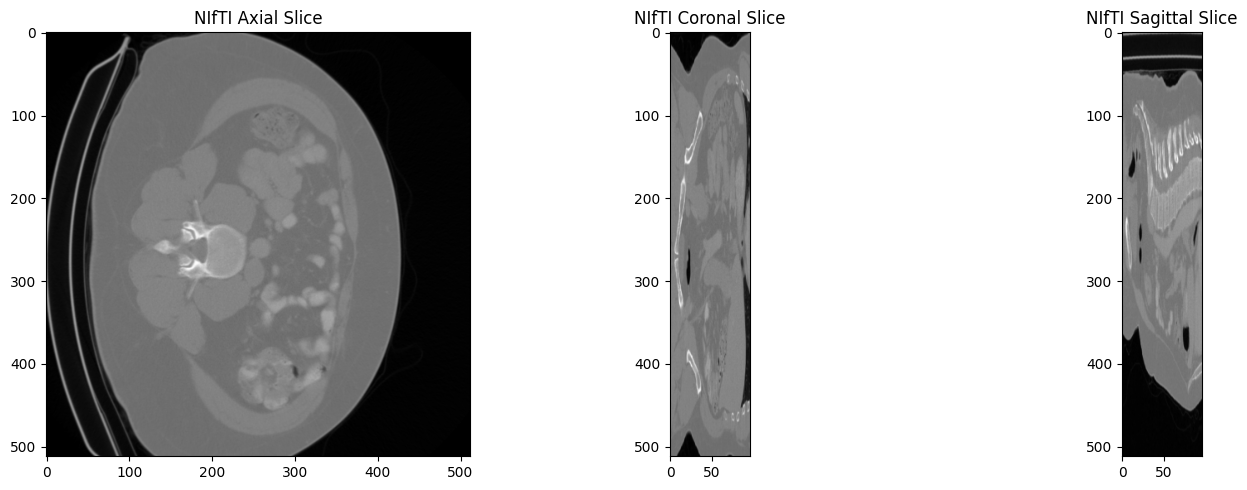

In [25]:
# Load NIfTI file
nifti_loader = LoadImage(image_only=True)
nifti_image = nifti_loader(nifti_filepath)
print(f"NIfTI image shape: {nifti_image.shape}")

# Visualize NIfTI image (middle slice) using matplotlib for axial, coronal, and sagittal views
plt.figure("NIfTI Visualization", (15, 5))
plt.subplot(1, 3, 1)
plt.title("NIfTI Axial Slice")
plt.imshow(nifti_image[..., nifti_image.shape[-1] // 2], cmap="gray")
plt.subplot(1, 3, 2)
plt.title("NIfTI Coronal Slice")
plt.imshow(nifti_image[:, nifti_image.shape[1] // 2, :], cmap="gray")
plt.subplot(1, 3, 3)
plt.title("NIfTI Sagittal Slice")
plt.imshow(nifti_image[nifti_image.shape[0] // 2, :, :], cmap="gray")
plt.tight_layout()
plt.show()

## DICOM Series Visualization
For DICOM series, MONAI's `LoadImage` can load a directory containing multiple DICOM files. We'll also apply some basic transforms like intensity scaling, orientation standardization, and resizing for consistent visualization.

DICOM image shape after transforms: torch.Size([1, 5, 128, 128])


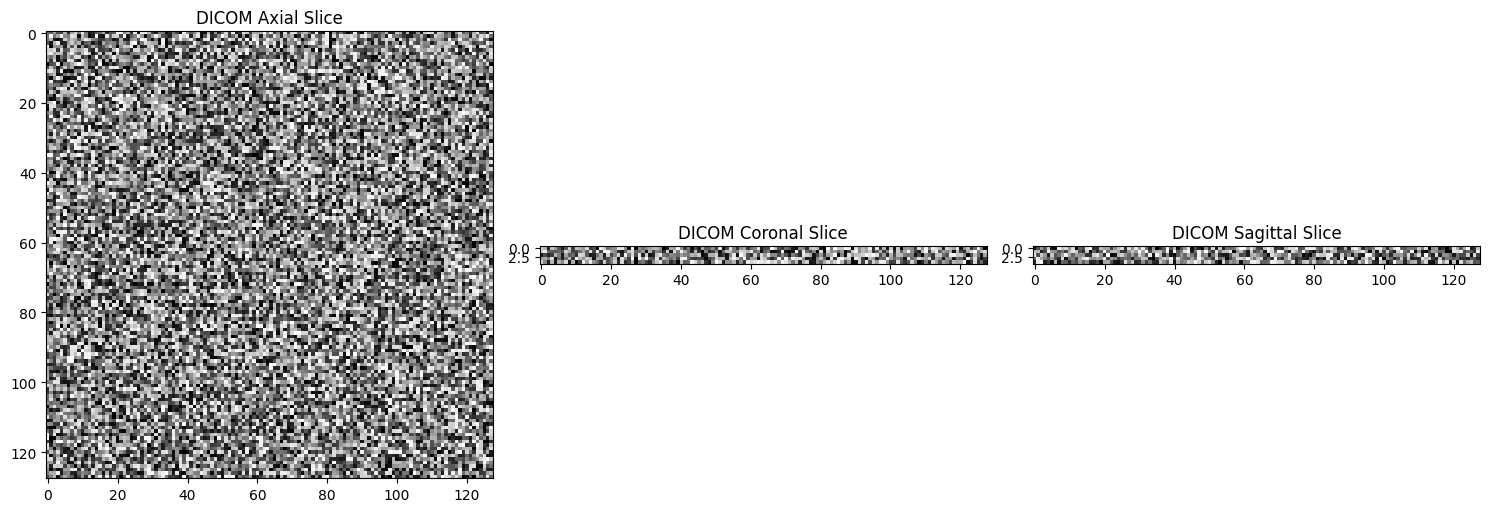

In [26]:
# Load DICOM series manually using pydicom, then apply MONAI transforms
dicom_files = sorted([os.path.join(dicom_series_dir, f) for f in os.listdir(dicom_series_dir) if f.endswith('.dcm')])

if not dicom_files:
    print(f"No DICOM files found in the directory: {dicom_series_dir}")
else:
    # Read all DICOM files and stack their pixel data
    slices = []
    for dcm_file in dicom_files:
        # Added force=True to handle cases where File Meta Information is missing (common with dummy files)
        ds = pydicom.dcmread(dcm_file, force=True)
        slices.append(ds.pixel_array)

    # Stack slices to form a 3D volume, typically along a new axis. Ensure consistent dimensions.
    # Assuming slices are 2D (height, width), stacking creates (num_slices, height, width)
    dicom_volume_np = np.stack(slices, axis=0).astype(np.float32) # Convert to float for transforms

    # MONAI transforms usually expect channel-first (B, C, H, W, D) or (C, H, W, D)
    # Add a channel dimension for grayscale images: (1, num_slices, height, width)
    dicom_volume_np = np.expand_dims(dicom_volume_np, axis=0) # Shape becomes (1, D, H, W)

    # Define MONAI transforms. Note: Orientation requires affine or metadata for proper working.
    # For dummy data, we'll focus on intensity and resizing.
    dicom_transform_pipeline = Compose([
        # Scale intensity to a common range (e.g., 0-1) for visualization
        ScaleIntensityRange(a_min=dicom_volume_np.min(), a_max=dicom_volume_np.max(), b_min=0.0, b_max=1.0, clip=True),
        # Resize to a consistent shape. Assuming D, H, W. If you have few slices, resizing Z might interpolate heavily.
        Resize(spatial_size=(len(dicom_files), 128, 128)) # Target (D, H, W)
    ])

    # Apply transforms. MONAI transforms are designed for (C, H, W, D) or (B, C, H, W, D)
    # The input shape to Resize should match (D, H, W) for spatial_size
    # Let's adjust the stack to (C, D, H, W) for MONAI compatibility with 3D data
    # dicom_volume_np is currently (1, D, H, W). We need (C, D, H, W) to match MONAI's Resize.
    # This matches the expected input of (channels, dim1, dim2, dim3) for a 3D image.
    dicom_image = dicom_transform_pipeline(dicom_volume_np)

    print(f"DICOM image shape after transforms: {dicom_image.shape}")

    # Visualize DICOM image using matplotlib for axial, coronal, and sagittal views
    # Assuming dicom_image is (C, D, H, W) after transforms
    # Adjust indices for visualization based on this shape
    plt.figure("DICOM Visualization", (15, 5))

    # Axial slice (across depth D)
    plt.subplot(1, 3, 1)
    plt.title("DICOM Axial Slice")
    plt.imshow(dicom_image[0, dicom_image.shape[1] // 2, :, :], cmap="gray")

    # Coronal slice (across height H)
    plt.subplot(1, 3, 2)
    plt.title("DICOM Coronal Slice")
    plt.imshow(dicom_image[0, :, dicom_image.shape[2] // 2, :], cmap="gray")

    # Sagittal slice (across width W)
    plt.subplot(1, 3, 3)
    plt.title("DICOM Sagittal Slice")
    plt.imshow(dicom_image[0, :, :, dicom_image.shape[3] // 2], cmap="gray")

    plt.tight_layout()
    plt.show()

## Clean Up
Finally, we'll remove the temporary directory and the dummy data we created.

In [6]:
import shutil
shutil.rmtree(data_dir)
print(f"Cleaned up temporary data directory: {data_dir}")

Cleaned up temporary data directory: /tmp/tmp4_sivnxg
